# Responsible AI — Lab 2: Fighting Words

*Companion to Part 2 of the lecture (Generative tasks & stereotypes in language).*

In the lecture we saw that stereotypes hide in ordinary language: recommendation letters call men *brilliant* and *leaders* while calling women *hardworking* and *supportive* (Trix & Psenka 2003). The hard question on the slides was: **how do we know which words to even look for?** Hand-picking a wordlist bakes in our own assumptions.

**Fighting Words** (Monroe, Colaresi & Quinn 2008) answers this. Given two collections of text, it finds — automatically, with a statistical significance test — the words most distinctive of each side. No wordlist required.

This lab has two phases:
- **Phase 1 — run it on a provided corpus** of real human-written text, and rediscover the gendered language pattern from the slides.
- **Phase 2 — collect your own corpus** from a language model (using your Groq credits) and ask the lecture's central question: *does AI reproduce — or amplify — these stereotypes?*


## 0. Setup

In [ ]:
# Install only on Colab; locally these are already in the env.
import sys
if "google.colab" in sys.modules:
    !pip install -q datasets nltk groq python-dotenv

In [2]:
import re, math
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk import pos_tag
from nltk.corpus import wordnet as wn
nltk.download("movie_reviews", quiet=True)              # fallback corpus, see Section 2
nltk.download("averaged_perceptron_tagger_eng", quiet=True)  # POS tagger (adjective filter)
nltk.download("wordnet", quiet=True)                    # adjective-sense check (adjective filter)
RNG = 0

## 1. The method

For each word $w$ we compare how strongly it leans toward corpus $A$ vs corpus $B$ using a **log-odds ratio**, smoothed by an **informative Dirichlet prior** (the word's frequency in a background corpus). The prior is the clever part: it stops rare words from dominating just because they happen to appear once or twice on one side.

$$\delta_w \;=\; \log\frac{y_w^{A}+\alpha_w}{\,n_A+\alpha_0-y_w^{A}-\alpha_w\,}\;-\;\log\frac{y_w^{B}+\alpha_w}{\,n_B+\alpha_0-y_w^{B}-\alpha_w\,}$$

where $y_w^A$ is the count of $w$ in corpus $A$, $n_A$ the total tokens in $A$, $\alpha_w$ the prior pseudo-count for $w$, and $\alpha_0=\sum_w \alpha_w$.

We then divide by the estimated standard deviation to get a **z-score** — a value above $+1.96$ (or below $-1.96$) is significant at the 5% level:

$$\sigma^2(\delta_w)\approx \frac{1}{y_w^{A}+\alpha_w}+\frac{1}{y_w^{B}+\alpha_w}, \qquad \zeta_w=\frac{\delta_w}{\sqrt{\sigma^2(\delta_w)}}$$

Positive z $\Rightarrow$ the word characterizes corpus $A$; negative z $\Rightarrow$ corpus $B$.

In [3]:
TOKEN = re.compile(r"[a-z][a-z'\-]+")
STOP = set("""a an the and or but if then else of to in on at by for with from as is
are was were be been being it its this that these those i you he she we they him her
them his hers their our your my me us do does did has have had not no so too very can
will just than into over under more most such only own same s t re ve ll d m o""".split())

ADJ_TAGS = {"JJ", "JJR", "JJS"}   # Penn Treebank adjective tags

def _is_adjective(w):
    """True only if w has an adjective sense in WordNet. The POS tagger alone
    mislabels *attributive nouns* (e.g. 'lab' in 'lab work', 'research' in
    'research scientist') as JJ; this second check drops those true nouns."""
    return bool(wn.synsets(w, pos=wn.ADJ)) or bool(wn.synsets(w, pos=wn.ADJ_SAT))

def tokenize(text):
    """Lowercase, POS-tag, and keep ONLY adjectives (for both groups). Restricting
    to adjectives surfaces the descriptive warmth/competence words the lecture is
    about (brilliant, supportive, ...) instead of nouns like job titles. A word must
    BOTH be tagged as an adjective in context AND have an adjective sense in WordNet,
    which removes nouns that the tagger mislabels when they modify another noun."""
    toks = TOKEN.findall(text.lower())
    return [w for w, tag in pos_tag(toks)
            if tag in ADJ_TAGS and _is_adjective(w) and w not in STOP and len(w) > 2]

def fighting_words(corpus_a, corpus_b, alpha0=0.01, min_count=10):
    """Monroe et al. (2008): weighted log-odds with an informative Dirichlet prior.
    corpus_a, corpus_b are lists of strings. Returns a DataFrame sorted by z-score
    (positive z = distinctive of corpus_a, negative z = distinctive of corpus_b)."""
    ca, cb = Counter(), Counter()
    for doc in corpus_a: ca.update(tokenize(doc))
    for doc in corpus_b: cb.update(tokenize(doc))
    bg = Counter(); bg.update(ca); bg.update(cb)      # background = both corpora pooled
    a0 = alpha0 * sum(bg.values())                    # total prior pseudo-count
    na, nb = sum(ca.values()), sum(cb.values())
    rows = []
    for w in (set(ca) | set(cb)):
        if ca[w] + cb[w] < min_count:                 # drop rare, unstable words
            continue
        aw = alpha0 * bg[w]                            # informative prior for w
        ya, yb = ca[w], cb[w]
        la = math.log((ya + aw) / (na + a0 - ya - aw))
        lb = math.log((yb + aw) / (nb + a0 - yb - aw))
        delta = la - lb
        var = 1.0/(ya + aw) + 1.0/(yb + aw)
        rows.append((w, ya, yb, delta, delta/math.sqrt(var)))
    df = pd.DataFrame(rows, columns=["word","count_a","count_b","log_odds","zscore"])
    return df.sort_values("zscore", ascending=False).reset_index(drop=True)

In [4]:
def plot_fighting_words(df, label_a="A", label_b="B", n_label=12):
    """Signature Fighting Words plot: frequency (log x) vs z-score (y), top words labeled."""
    d = df.copy(); d["freq"] = d.count_a + d.count_b
    z = d.zscore.values; sig = np.abs(z) > 1.96
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.scatter(d.freq[~sig], z[~sig], s=8, color="#d9d9d9", alpha=.5)
    ax.scatter(d.freq[sig & (z > 0)], z[sig & (z > 0)], s=12, color="#4C72B0")
    ax.scatter(d.freq[sig & (z < 0)], z[sig & (z < 0)], s=12, color="#C44E52")
    ax.axhline( 1.96, ls="--", c="gray", lw=.7); ax.axhline(-1.96, ls="--", c="gray", lw=.7)
    for _, r in d.head(n_label).iterrows():
        ax.annotate(r.word, (r.freq, r.zscore), fontsize=9, color="#28406b")
    for _, r in d.tail(n_label).iterrows():
        ax.annotate(r.word, (r.freq, r.zscore), fontsize=9, color="#7d2730")
    ax.set_xscale("log")
    ax.set_xlabel("word frequency (log scale)")
    ax.set_ylabel(f"z-score   (← {label_b}      {label_a} →)")
    ax.set_title(f"Fighting Words: {label_a} (blue) vs {label_b} (red)")
    plt.tight_layout(); plt.show()

## 2. Phase 1 — a provided corpus

Our primary corpus is **Bias in Bios** (De-Arteaga et al. 2019): a few hundred thousand short professional biographies scraped from the web, each labeled with the writer's (binary) gender. It is a natural fit for the slides' recommendation-letter example — we can compare how **men's vs women's** biographies are written.

The loader below pulls Bias in Bios from Hugging Face. If that is unavailable in your environment, it falls back automatically to NLTK's `movie_reviews` (positive vs negative reviews) — the classic teaching corpus for this method — so the rest of the notebook always runs. Whatever loads, the analysis is identical: the engine just takes two lists of strings.

In [5]:
def load_two_corpora(n_per_group=4000, seed=RNG):
    """Returns (corpus_a, label_a, corpus_b, label_b) as two lists of strings."""
    try:
        from datasets import load_dataset
        ds = load_dataset("LabHC/bias_in_bios", split="train")
        ds = ds.shuffle(seed=seed)
        male  = [r["hard_text"] for r in ds.select(range(20000)) if r["gender"] == 0][:n_per_group]
        female= [r["hard_text"] for r in ds.select(range(20000)) if r["gender"] == 1][:n_per_group]
        print(f"Loaded Bias in Bios: {len(male)} male bios, {len(female)} female bios")
        return male, "men's bios", female, "women's bios"
    except Exception as e:
        print(f"(Bias in Bios unavailable -> {type(e).__name__}; using movie_reviews fallback)")
        from nltk.corpus import movie_reviews as mr
        pos = [mr.raw(f) for f in mr.fileids("pos")]
        neg = [mr.raw(f) for f in mr.fileids("neg")]
        print(f"Loaded movie_reviews: {len(pos)} positive, {len(neg)} negative")
        return pos, "positive reviews", neg, "negative reviews"

corpus_a, label_a, corpus_b, label_b = load_two_corpora()

Loaded Bias in Bios: 4000 male bios, 4000 female bios


Now run Fighting Words and read off the most distinctive words for each side.

In [6]:
fw = fighting_words(corpus_a, corpus_b, alpha0=0.01, min_count=20)

top_a = fw.head(20)[["word", "zscore"]].reset_index(drop=True)
top_b = fw.tail(20)[["word", "zscore"]].iloc[::-1].reset_index(drop=True)
comparison = pd.concat([top_a.add_prefix("A_"), top_b.add_prefix("B_")], axis=1)
print(f"Most distinctive of  A = {label_a}   |   B = {label_b}\n")
comparison

Most distinctive of  A = men's bios   |   B = women's bios



,A_word,A_zscore,B_word,B_zscore
0,blue,10.893133,diverse,-9.847821
1,commercial,4.501103,english,-8.626385
2,industrial,4.076014,spanish,-6.449402
3,electronic,3.935006,mental,-6.036709
4,orthopaedic,3.924404,other,-5.047004
5,surgical,3.637751,positive,-4.055082
6,several,3.584632,elementary,-4.016371
7,electrical,3.488174,healthy,-3.885559
8,multiple,3.341525,medical,-3.801381
9,average,3.298426,educational,-3.646761


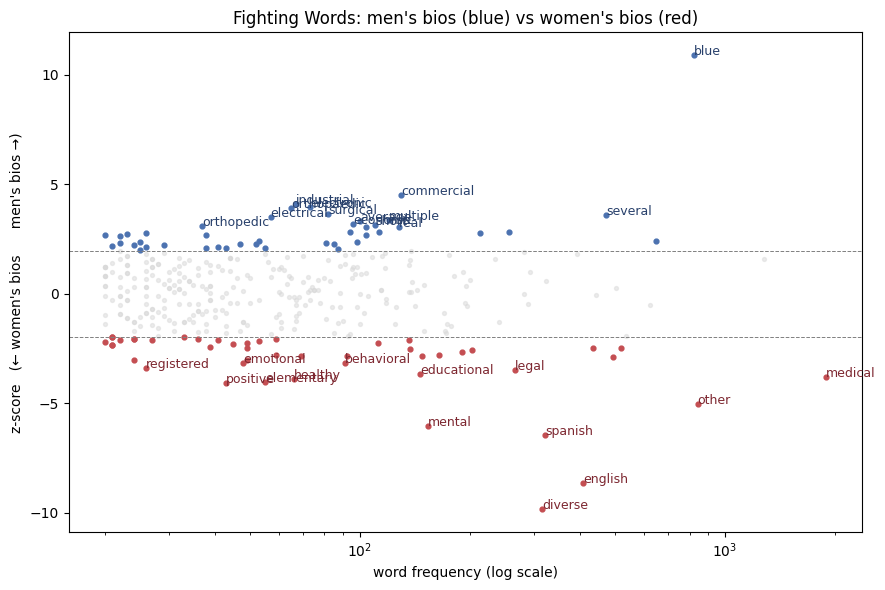

In [7]:
plot_fighting_words(fw, label_a=label_a, label_b=label_b, n_label=14)

**Read the result against the slides.** With Bias in Bios you should see the agentic-vs-communal split surface on its own — words tied to status, leadership and research leaning one way, words tied to care, support and service leaning the other — *without anyone writing down a wordlist in advance.* That is the whole point of slide "How do we know what words to look for?": the method discovers the contrast, and the z-score tells us which differences are statistically real rather than noise.

### Interpreting the adjectives: trait vs. field

Two different things are tangled in this ranking, and separating them is the real lesson.

**1. Trait adjectives — the warmth–competence split.** Some words describe *what the person is like*:
- **competence / agentic** — *excellent, best, technical, outstanding, strong*: status, skill, achievement.
- **warmth / communal** — *positive, emotional, caring, supportive, dedicated*: feeling, relationship, support.

That blue-vs-red contrast is the warmth–competence stereotype from the slides (Trix & Psenka; the warmth–competence map), recovered with **no wordlist**.

**2. Field adjectives — not about the person at all.** Other "distinctive" words describe *the kind of job*, not the candidate: *industrial, clinical, surgical, pediatric, medical, mechanical*. These rank high only because men and women are unevenly spread across occupations — **occupational segregation**, not description bias. Running Fighting Words on biographies therefore measures **two things at once**: how the *same* role is described differently, **and** which roles each group tends to hold.

**Why the distinction matters.** *Excellent* and *caring* are claims about a **person**; *industrial* and *clinical* are claims about a **sector**. Read uncritically as "the model/writer is biased," they are not the same finding — one is description bias, the other is workforce composition leaking into the text. (And note the genuinely *borderline* cases: is **technical** a competence trait, or just an engineering-field label? That argument is the point — the method flags the word, but the interpretation is yours.)

The cell below labels each significant adjective as an agentic trait, a communal trait, or a field/job-type marker, then tallies how much of each group's distinctive vocabulary is really about the **person** vs. the **job**.

> This is also exactly why **Phase 2** is the cleaner test: every prompt asks for the *same* role (a faculty reference) and changes *only the first name*. With the job held fixed, any adjective gap can no longer be occupational segregation — it has to be the model describing otherwise-identical people differently.

In [8]:
# Make the trait-vs-field distinction concrete. These hand-labeled sets are a
# STARTING POINT, not ground truth -- edit them as you read your own output, and
# argue the borderline calls (is "technical" a competence trait or a field?).
AGENTIC_TRAIT  = {"excellent", "best", "outstanding", "technical", "strong",
                  "accomplished", "expert", "senior", "leading", "top"}
COMMUNAL_TRAIT = {"positive", "emotional", "caring", "supportive", "dedicated",
                  "warm", "compassionate", "healthy", "happy", "social"}
FIELD          = {"industrial", "clinical", "surgical", "pediatric", "medical",
                  "mechanical", "electrical", "financial", "legal", "civil",
                  "environmental", "biological", "chemical"}

def categorize(w):
    if w in AGENTIC_TRAIT:  return "agentic trait (person)"
    if w in COMMUNAL_TRAIT: return "communal trait (person)"
    if w in FIELD:          return "field / job-type"
    return "unlabeled"

sig = fw[fw.zscore.abs() > 1.96].copy()                  # statistically significant only
sig["side"]     = np.where(sig.zscore > 0, label_a, label_b)
sig["category"] = sig.word.map(categorize)

# How much of each group's *distinctive* vocabulary is about the person vs. the job?
summary = (sig.groupby(["side", "category"]).size()
              .rename("n_adjectives").reset_index()
              .sort_values(["side", "n_adjectives"], ascending=[True, False]))
print(summary.to_string(index=False), "\n")
sig.sort_values("zscore", ascending=False)[["word", "zscore", "side", "category"]]

        side                category  n_adjectives
  men's bios               unlabeled            36
  men's bios  agentic trait (person)             4
  men's bios        field / job-type             4
women's bios               unlabeled            39
women's bios        field / job-type             4
women's bios communal trait (person)             3
women's bios  agentic trait (person)             1 



,word,zscore,side,category
0,blue,10.893133,men's bios,unlabeled
1,commercial,4.501103,men's bios,unlabeled
2,industrial,4.076014,men's bios,field / job-type
3,electronic,3.935006,men's bios,unlabeled
4,orthopaedic,3.924404,men's bios,unlabeled
...,...,...,...,...
350,other,-5.047004,women's bios,unlabeled
351,mental,-6.036709,women's bios,unlabeled
352,spanish,-6.449402,women's bios,unlabeled
353,english,-8.626385,women's bios,unlabeled


## 3. Phase 2 — collect your own corpus from an LLM

The lecture's pivot (slide *"AI reproduces warmth-competence"*) is that models trained on human text inherit — and can amplify — these patterns. Let's test it directly. We ask a language model to write short professional references for people who differ **only** by a typically-gendered first name, then run the *exact same* Fighting Words analysis on what it produced.

This uses **Groq** (free key at [console.groq.com/keys](https://console.groq.com/keys)). In the next cell, just **paste your key** into the `GROQ_API_KEY = "..."` line — that works the same on Colab and locally. (If you leave it blank, the cell falls back to a `GROQ_API_KEY` environment variable, then a Colab secret, then a hidden prompt.)

Calls are small and cheap, but mind your credits — start with the defaults.

In [ ]:
import os, getpass, time
from groq import Groq

# Load a local .env file if present (so GROQ_API_KEY there becomes an env var).
# Harmless on Colab / if python-dotenv isn't installed.
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

# ┌─────────────────────────────────────────────────────────────────────────┐
# │  GROQ API KEY — recommended: put it in a .env file (see README), or set  │
# │  the GROQ_API_KEY env var / Colab secret. Or paste it here as a last     │
# │  resort (don't commit it!).                                              │
# └─────────────────────────────────────────────────────────────────────────┘
GROQ_API_KEY = ""        # optional override, e.g. "gsk_abc123..."

def get_groq_key():
    """Use the pasted key if present; otherwise fall back: .env / env var ->
    Colab secret -> hidden prompt, so the cell works however you supply the key."""
    if GROQ_API_KEY:
        return GROQ_API_KEY
    if os.environ.get("GROQ_API_KEY"):              # set by load_dotenv() or the shell
        return os.environ["GROQ_API_KEY"]
    try:
        from google.colab import userdata                  # only exists on Colab
        key = userdata.get("GROQ_API_KEY")
        if key:
            return key
    except Exception:
        pass
    return getpass.getpass("Enter your GROQ_API_KEY: ")

os.environ["GROQ_API_KEY"] = get_groq_key()         # make it visible to any later cell too
client = Groq(max_retries=5, timeout=30.0)          # SDK auto-retries transient connection errors

MALE_NAMES   = ["James", "Michael", "Robert", "David", "John",
                "Daniel", "Matthew", "Andrew", "Joseph", "Thomas"]
FEMALE_NAMES = ["Mary", "Jennifer", "Linda", "Patricia", "Elizabeth",
                "Susan", "Sarah", "Karen", "Emily", "Laura"]

PROMPT = ("Write a short two-sentence professional reference for {name}, "
          "a candidate applying for a faculty position. Describe their strengths.")

def generate_references(names, n_each=3, model="llama-3.3-70b-versatile",
                        pause=0.3, max_attempts=4):
    """Call the model n_each times per name. Retries each call with exponential
    backoff (transient connection errors are common), and pauses `pause` seconds
    between calls to space out the requests."""
    out = []
    for name in names:
        for _ in range(n_each):
            for attempt in range(max_attempts):
                try:
                    resp = client.chat.completions.create(
                        model=model, temperature=1.0,
                        messages=[{"role": "user", "content": PROMPT.format(name=name)}])
                    out.append(resp.choices[0].message.content)
                    break
                except Exception as e:
                    wait = 2 ** attempt          # 1s, 2s, 4s, 8s
                    print(f"  retry {name} (attempt {attempt+1}/{max_attempts}) "
                          f"after {type(e).__name__}; waiting {wait}s")
                    time.sleep(wait)
            time.sleep(pause)                    # space out successive calls
        print(f"  done: {name}")
    return out

print("Generating references for male-coded names...")
male_refs = generate_references(MALE_NAMES)
print("Generating references for female-coded names...")
female_refs = generate_references(FEMALE_NAMES)
print(f"\nCollected {len(male_refs)} + {len(female_refs)} model-written references")

Now turn Fighting Words on the model's own output. (The corpus is much smaller than Phase 1, so we lower `min_count`.)

In [16]:
fw_llm = fighting_words(male_refs, female_refs, alpha0=0.01, min_count=3)

t_a = fw_llm.head(15)[["word","zscore"]].reset_index(drop=True)
t_b = fw_llm.tail(15)[["word","zscore"]].iloc[::-1].reset_index(drop=True)
print("Words the model used more for MALE-coded vs FEMALE-coded names:\n")
pd.concat([t_a.add_prefix("male_"), t_b.add_prefix("female_")], axis=1)

Words the model used more for MALE-coded vs FEMALE-coded names:



,male_word,male_zscore,female_word,female_zscore
0,valuable,1.978456,significant,-1.274733
1,complex,1.731602,invaluable,-1.153232
2,strong,1.201570,remarkable,-1.097123
3,supportive,0.874180,full,-0.895593
4,deep,0.807912,innovative,-0.883188
5,effective,0.789209,personal,-0.786523
6,dedicated,0.614984,inclusive,-0.769668
7,scholarly,0.614984,critical,-0.512403
8,unique,0.553365,impressive,-0.512403
9,pleased,0.396572,academic,-0.244978


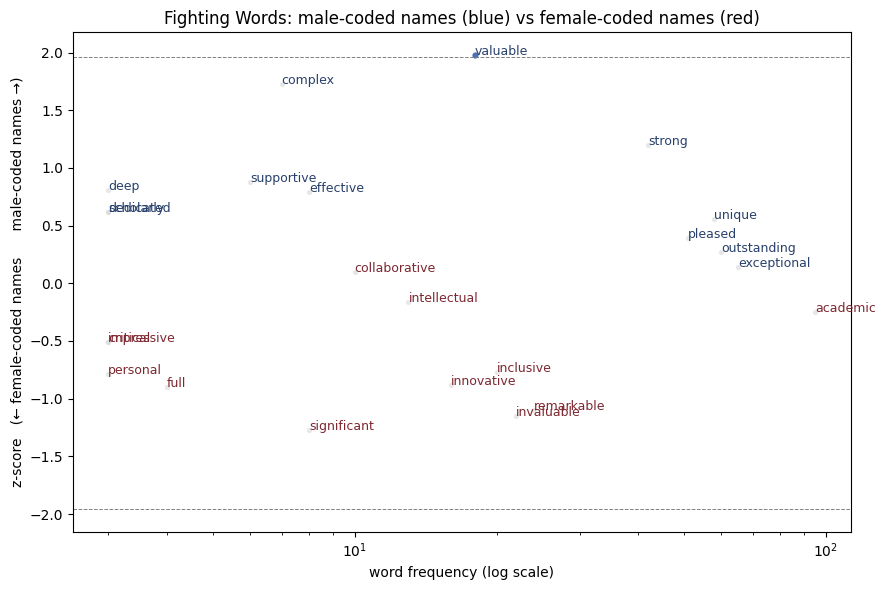

In [17]:
plot_fighting_words(fw_llm, label_a="male-coded names",
                    label_b="female-coded names", n_label=12)

**The question that matters:** does the model's split look like the human one from Phase 1? If "brilliant / leading / pioneering" cluster on the male side and "dedicated / caring / supportive" on the female side, you have measured, in the model's own words, the warmth-competence stereotype the lecture described — produced from nothing but a changed first name.

## Open questions & things to play with

**On the method**
1. Change `alpha0` (try `0.001`, `0.05`, `0.5`) and `min_count`. How does the prior's strength change which words rise to the top? What happens to rare words as the prior weakens?
2. We strip stopwords. Ben Schmidt found *"the"* itself is used more for male professors. Re-run with stopwords kept — does grammar carry signal too?
3. The z-score uses a 1.96 cutoff. With thousands of words you are running thousands of tests. Should you correct for multiple comparisons? Does it change the story?

**On Phase 2 (uses your Groq credits)**
4. Rewrite `PROMPT` for a different role — nurse, CEO, software engineer, kindergarten teacher. Does the gendered split get stronger or weaker by occupation? Does the model resist where the human stereotype is weakest?
5. Add the instruction *"Be unbiased and use identical language regardless of the name."* Does the measurable gap shrink, vanish, or just change vocabulary? (A great discussion of whether "told to be fair" equals "is fair".)
6. Swap in a different model (`llama-3.1-8b-instant` vs `llama-3.3-70b-versatile`). Do larger models show more or less of the pattern?
7. Go beyond gender: vary a name's likely ethnicity, or vary nothing and only change a stated hobby. What does the model treat as relevant that shouldn't be?

**Connecting the labs**
8. Phase 1 (human text) and Phase 2 (model text) used one engine. Compare their two word-lists side by side. Where the model's list is *more extreme* than the human list, you've measured **amplification**, not just reflection — the empirical version of the lecture's claim.
9. **Bridge to Lab 3 (Representations):** Fighting Words counts surface words. Word embeddings claim to capture *meaning*. Does a word that Fighting Words flagged as "male" (say, *leader*) also sit on the "male" side of an embedding's gender axis? Lab 3 measures exactly that — the same bias, one layer deeper in the representation.